# Fraud Rule Discovery using Explainable Machine Learning

This notebook discovers **fraud detection rules** from the Fake Job Postings dataset using a combination of:

- Exploratory Data Analysis (EDA)
- LightGBM Feature Importance
- SHAP Explainability
- Explainable Boosting Machines (EBM)

The objective is to extract **interpretable fraud detection rules** that will be integrated into the **Metadata Anomaly Detector (Tool-2)** of our agentic fraud detection system.

Dataset:
Fake Job Postings (EMSCAD)

In [1]:
import sys
print(sys.executable)

d:\anaconda3\envs\jobfraud\python.exe


# Import Libraries

In [3]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

import lightgbm as lgb

import shap

from interpret.glassbox import ExplainableBoostingClassifier
from interpret import show

## Load Dataset

In [4]:
DATA_PATH = "../data/raw/fake_job_postings.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)

df.head()

Dataset shape: (17880, 18)


,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,5,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0


## Class Distribution

Fraudulent listings are extremely rare (~5%).  
This imbalance makes fraud detection challenging.

In [5]:
df["fraudulent"].value_counts(normalize=True)

fraudulent
0    0.951566
1    0.048434
Name: proportion, dtype: float64

## Missing Value Analysis

Fraudulent postings often omit important company metadata.

In [6]:
missing = df.isnull().mean().sort_values(ascending=False)

missing.head(15)

salary_range           0.839597
department             0.645805
required_education     0.453300
benefits               0.403356
required_experience    0.394295
function               0.361018
industry               0.274217
employment_type        0.194128
company_profile        0.185011
requirements           0.150783
location               0.019351
description            0.000056
title                  0.000000
job_id                 0.000000
telecommuting          0.000000
dtype: float64

## Metadata Feature Engineering

We construct metadata features that capture fraud signals.

In [7]:
df["missing_company_profile"] = df["company_profile"].isna().astype(int)
df["missing_salary"] = df["salary_range"].isna().astype(int)
df["missing_department"] = df["department"].isna().astype(int)

## Metadata Features for Rule Discovery

In [8]:
metadata_features = [
    "telecommuting",
    "has_company_logo",
    "has_questions",
    "missing_company_profile",
    "missing_salary",
    "missing_department",
    "required_experience",
    "required_education",
    "industry"
]

X = df[metadata_features].copy()
y = df["fraudulent"]

## Encoding Categorical Variables

In [9]:
for col in X.select_dtypes(include="object").columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))

In [11]:
#@title: Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

## Train LightGBM Model

LightGBM performs very well on tabular data and helps identify important fraud indicators.

In [12]:
model = lgb.LGBMClassifier(
    n_estimators=600,
    learning_rate=0.03,
    max_depth=6,
    random_state=42
)

model.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 693, number of negative: 13611
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001733 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 153
[LightGBM] [Info] Number of data points in the train set: 14304, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.048448 -> initscore=-2.977604
[LightGBM] [Info] Start training from score -2.977604
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,6
,learning_rate,0.03
,n_estimators,600
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


## Feature Importance (LightGBM)

In [13]:
importance = pd.DataFrame({
    "feature": X.columns,
    "importance": model.feature_importances_
})

importance = importance.sort_values("importance", ascending=False)

importance

,feature,importance
8,industry,7170
7,required_education,2879
6,required_experience,2836
4,missing_salary,1156
2,has_questions,1028
5,missing_department,940
1,has_company_logo,637
3,missing_company_profile,624
0,telecommuting,534


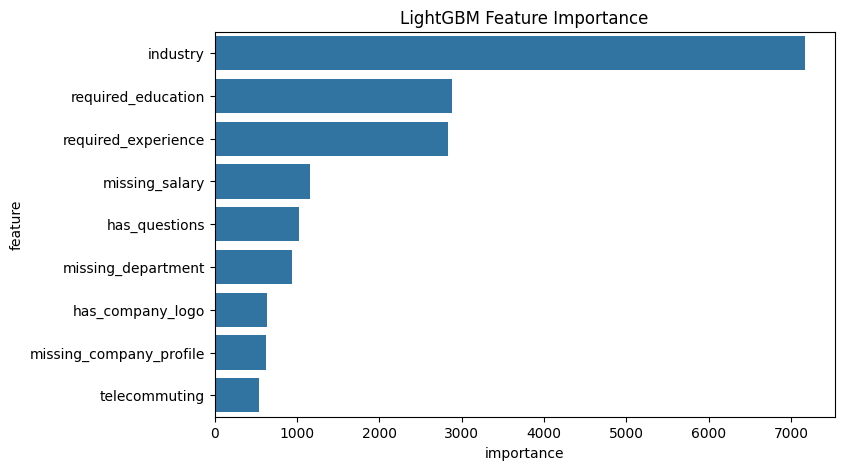

In [14]:
plt.figure(figsize=(8,5))

sns.barplot(data=importance, x="importance", y="feature")

plt.title("LightGBM Feature Importance")

plt.show()

## SHAP Explainability

SHAP values show how each feature contributes to fraud predictions.

In [15]:
explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X_train)

d:\anaconda3\envs\jobfraud\lib\site-packages\shap\explainers\_tree.py:586: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


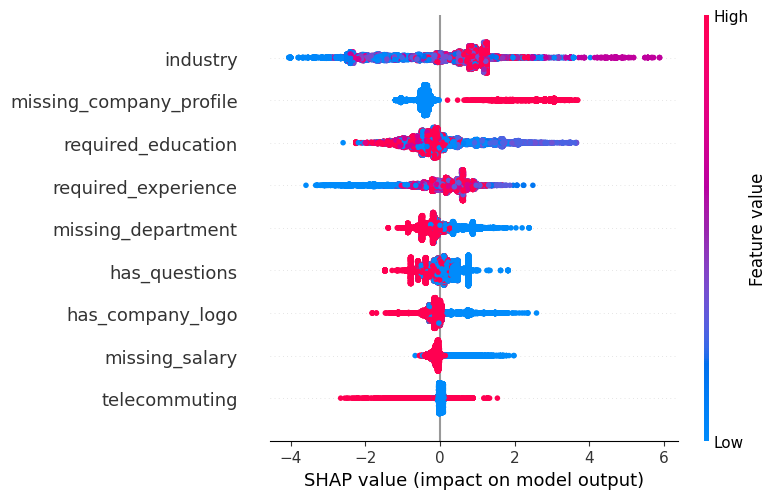

In [16]:
shap.summary_plot(shap_values, X_train)

## SHAP Dependence Example

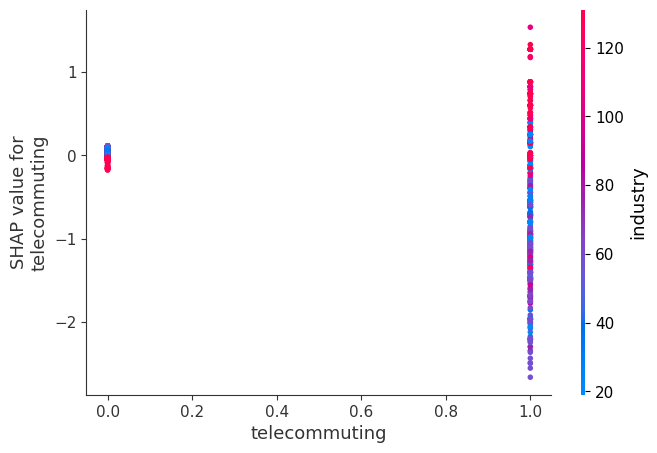

In [17]:
shap.dependence_plot("telecommuting", shap_values, X_train)

## Explainable Boosting Machine (EBM)

EBM automatically learns interpretable feature contributions.

In [18]:
ebm = ExplainableBoostingClassifier(
    interactions=5,
    learning_rate=0.01,
    max_bins=256,
    random_state=42
)

ebm.fit(X_train, y_train)

,feature_names,None
,feature_types,None
,max_bins,256
,max_interaction_bins,64
,interactions,5
,exclude,None
,validation_size,0.15
,outer_bags,14
,inner_bags,0
,learning_rate,0.01
,greedy_ratio,10.0


In [19]:
ebm_global = ebm.explain_global()

show(ebm_global)

<!-- http://127.0.0.1:7001/1562505350112/ -->

## Extract Fraud Rules from EBM

In [21]:
rules = []

for i, feature in enumerate(metadata_features):

    data = ebm_global.data(i)

    names = data["names"]
    scores = data["scores"]

    for val, score in zip(names, scores):

        if score > 0.3:  # strong fraud signal

            rules.append({
                "feature": feature,
                "value": val,
                "score": score
            })

rules

[{'feature': 'has_company_logo',
  'value': np.float64(0.0),
  'score': np.float64(0.7028547481324504)},
 {'feature': 'missing_company_profile',
  'value': np.float64(0.5),
  'score': np.float64(1.5879840166705301)},
 {'feature': 'missing_salary',
  'value': np.float64(0.0),
  'score': np.float64(0.363766272327245)},
 {'feature': 'missing_department',
  'value': np.float64(0.0),
  'score': np.float64(0.3339739276344088)},
 {'feature': 'required_experience',
  'value': np.float64(0.5),
  'score': np.float64(0.3621098427258561)},
 {'feature': 'required_experience',
  'value': np.float64(6.5),
  'score': np.float64(0.35688789584392033)},
 {'feature': 'required_education',
  'value': np.float64(1.5),
  'score': np.float64(0.5966767604333779)},
 {'feature': 'required_education',
  'value': np.float64(2.5),
  'score': np.float64(0.5488848526998935)},
 {'feature': 'required_education',
  'value': np.float64(3.5),
  'score': np.float64(0.9187309747364837)},
 {'feature': 'required_education',
 